# NSL-KDD Unsupervised Anomaly Detection - Part 1: Data Exploration

**Project Goal:** Discover attack signatures and detect network intrusions using unsupervised learning

**Dataset:** NSL-KDD Network Intrusion Detection Dataset
- 125,973 training records
- 41 features + 1 label + 1 difficulty score
- Attack types: Normal, DoS, Probe, R2L, U2R

**Notebook Outline:**
1. Data Loading & Column Definitions
2. Initial Data Inspection
3. Exploratory Data Analysis (EDA)
4. Feature Type Analysis
5. Class Distribution Analysis
6. Next Steps

---
## 1. Setup & Data Loading

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Plotting configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


### Define Column Names

NSL-KDD has 41 features across 4 categories:
- **Basic features (9):** Connection-level attributes
- **Content features (13):** Domain knowledge features 
- **Traffic features (9):** Time-window based statistics
- **Host-based features (10):** Similar connections statistics

In [2]:
# Define all 41 feature names + label + difficulty
column_names = [
    # Basic features (1-9)
    'duration',              # Length of connection (seconds)
    'protocol_type',         # Protocol: tcp, udp, icmp
    'service',               # Network service: http, ftp, smtp, etc.
    'flag',                  # Connection status: SF, S0, REJ, etc.
    'src_bytes',             # Bytes from source to destination
    'dst_bytes',             # Bytes from destination to source
    'land',                  # 1 if connection is from/to same host/port
    'wrong_fragment',        # Number of wrong fragments
    'urgent',                # Number of urgent packets
    
    # Content features (10-22)
    'hot',                   # Number of 'hot' indicators
    'num_failed_logins',     # Number of failed login attempts
    'logged_in',             # 1 if successfully logged in
    'num_compromised',       # Number of compromised conditions
    'root_shell',            # 1 if root shell obtained
    'su_attempted',          # 1 if su root command attempted
    'num_root',              # Number of root accesses
    'num_file_creations',    # Number of file creation operations
    'num_shells',            # Number of shell prompts
    'num_access_files',      # Number of operations on access control files
    'num_outbound_cmds',     # Number of outbound commands
    'is_host_login',         # 1 if login belongs to host list
    'is_guest_login',        # 1 if login is guest
    
    # Traffic features - same host (23-31)
    'count',                 # Connections to same host in past 2 seconds
    'srv_count',             # Connections to same service in past 2 seconds
    'serror_rate',           # % of connections with SYN errors
    'srv_serror_rate',       # % of connections with SYN errors (same service)
    'rerror_rate',           # % of connections with REJ errors
    'srv_rerror_rate',       # % of connections with REJ errors (same service)
    'same_srv_rate',         # % of connections to same service
    'diff_srv_rate',         # % of connections to different services
    'srv_diff_host_rate',    # % of connections to different hosts (same service)
    
    # Host-based features - same destination (32-41)
    'dst_host_count',        # Connections to same destination host
    'dst_host_srv_count',    # Connections to same destination host/service
    'dst_host_same_srv_rate',      # % same service on destination
    'dst_host_diff_srv_rate',      # % different services on destination
    'dst_host_same_src_port_rate', # % same source port on destination
    'dst_host_srv_diff_host_rate', # % different source hosts for service
    'dst_host_serror_rate',        # % SYN errors on destination
    'dst_host_srv_serror_rate',    # % SYN errors (same service) on destination
    'dst_host_rerror_rate',        # % REJ errors on destination  
    'dst_host_srv_rerror_rate',    # % REJ errors (same service) on destination
    
    # Label
    'attack_type',           # Attack type: normal, dos, probe, r2l, u2r
    'difficulty_level'       # Difficulty level (not used in analysis)
]

print(f"Total columns defined: {len(column_names)}")
print(f"Expected: 41 features + 1 label + 1 difficulty = 43 columns")

Total columns defined: 43
Expected: 41 features + 1 label + 1 difficulty = 43 columns


### Load the Dataset

In [3]:
# Load training data
data_path = 'KDDTrain+.txt'

print("Loading NSL-KDD training data...")
df = pd.read_csv(data_path, names=column_names, header=None)

print(f"\n✓ Data loaded successfully!")
print(f"Dataset shape: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Loading NSL-KDD training data...

✓ Data loaded successfully!
Dataset shape: (125973, 43)
Memory usage: 66.93 MB


---
## 2. Initial Data Inspection

In [4]:
# First look at the data
df.head(10)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack_type,difficulty_level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,0.0,0.0,0.0,0.0,1.00,0.00,0.00,150,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,1,0.0,0.0,0.0,0.0,0.08,0.15,0.00,255,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,123,6,1.0,1.0,0.0,0.0,0.05,0.07,0.00,255,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,5,5,0.2,0.2,0.0,0.0,1.00,0.00,0.00,30,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,30,32,0.0,0.0,0.0,0.0,1.00,0.00,0.09,255,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21
5,0,tcp,private,REJ,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,121,19,0.0,0.0,1.0,1.0,0.16,0.06,0.00,255,19,0.07,0.07,0.00,0.00,0.00,0.00,1.00,1.00,neptune,21
6,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,166,9,1.0,1.0,0.0,0.0,0.05,0.06,0.00,255,9,0.04,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,21
7,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,117,16,1.0,1.0,0.0,0.0,0.14,0.06,0.00,255,15,0.06,0.07,0.00,0.00,1.00,1.00,0.00,0.00,neptune,21
8,0,tcp,remote_job,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,270,23,1.0,1.0,0.0,0.0,0.09,0.05,0.00,255,23,0.09,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,21
9,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,133,8,1.0,1.0,0.0,0.0,0.06,0.06,0.00,255,13,0.05,0.06,0.00,0.00,1.00,1.00,0.00,0.00,neptune,21


In [5]:
# Data types
print("Data types:")
print(df.dtypes.value_counts())
print("\nColumn types breakdown:")
print(df.dtypes)

Data types:
int64      24
float64    15
object      4
Name: count, dtype: int64

Column types breakdown:
duration                         int64
protocol_type                   object
service                         object
flag                            object
src_bytes                        int64
dst_bytes                        int64
land                             int64
wrong_fragment                   int64
urgent                           int64
hot                              int64
num_failed_logins                int64
logged_in                        int64
num_compromised                  int64
root_shell                       int64
su_attempted                     int64
num_root                         int64
num_file_creations               int64
num_shells                       int64
num_access_files                 int64
num_outbound_cmds                int64
is_host_login                    int64
is_guest_login                   int64
count                            int6

In [6]:
# Basic statistics for numerical features
df.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,difficulty_level
count,125973.00000,1.259730e+05,1.259730e+05,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.0,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000
mean,287.14465,4.556674e+04,1.977911e+04,0.000198,0.022687,0.000111,0.204409,0.001222,0.395736,0.279250,0.001342,0.001103,0.302192,0.012669,0.000413,0.004096,0.0,0.000008,0.009423,84.107555,27.737888,0.284485,0.282485,0.119958,0.121183,0.660928,0.063053,0.097322,182.148945,115.653005,0.521242,0.082951,0.148379,0.032542,0.284452,0.278485,0.118832,0.120240,19.504060
std,2604.51531,5.870331e+06,4.021269e+06,0.014086,0.253530,0.014366,2.149968,0.045239,0.489010,23.942042,0.036603,0.045154,24.399618,0.483935,0.022181,0.099370,0.0,0.002817,0.096612,114.508607,72.635840,0.446456,0.447022,0.320436,0.323647,0.439623,0.180314,0.259830,99.206213,110.702741,0.448949,0.188922,0.308997,0.112564,0.444784,0.445669,0.306557,0.319459,2.291503
min,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.090000,0.000000,0.000000,82.000000,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000
50%,0.00000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,14.000000,8.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,255.000000,63.000000,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000
75%,0.00000,2.760000e+02,5.160000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,143.000000,18.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.060000,0.000000,255.000000,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000,21.000000
max,42908.00000,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,77.000000,5.000000,1.000000,7479.000000,1.000000,2.000000,7468.000000,43.000000,2.000000,9.000000,0.0,1.000000,1.000000,511.000000,511.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,255.000000,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,21.000000


In [7]:
# Check for missing values
missing = df.isnull().sum()
if missing.sum() > 0:
    print("Missing values found:")
    print(missing[missing > 0])
else:
    print("✓ No missing values in the dataset!")

✓ No missing values in the dataset!


In [8]:
# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates} ({duplicates/len(df)*100:.2f}%)")

Duplicate rows: 0 (0.00%)


---
## 3. Feature Type Analysis

Identify categorical vs numerical features

In [9]:
# Identify categorical features (excluding label and difficulty)
categorical_features = ['protocol_type', 'service', 'flag']

# All other features are numerical (excluding attack_type and difficulty_level)
numerical_features = [col for col in df.columns if col not in categorical_features + ['attack_type', 'difficulty_level']]

print(f"Categorical features ({len(categorical_features)}): {categorical_features}")
print(f"\nNumerical features ({len(numerical_features)}):")
for i, feat in enumerate(numerical_features, 1):
    print(f"{i:2d}. {feat}")

Categorical features (3): ['protocol_type', 'service', 'flag']

Numerical features (38):
 1. duration
 2. src_bytes
 3. dst_bytes
 4. land
 5. wrong_fragment
 6. urgent
 7. hot
 8. num_failed_logins
 9. logged_in
10. num_compromised
11. root_shell
12. su_attempted
13. num_root
14. num_file_creations
15. num_shells
16. num_access_files
17. num_outbound_cmds
18. is_host_login
19. is_guest_login
20. count
21. srv_count
22. serror_rate
23. srv_serror_rate
24. rerror_rate
25. srv_rerror_rate
26. same_srv_rate
27. diff_srv_rate
28. srv_diff_host_rate
29. dst_host_count
30. dst_host_srv_count
31. dst_host_same_srv_rate
32. dst_host_diff_srv_rate
33. dst_host_same_src_port_rate
34. dst_host_srv_diff_host_rate
35. dst_host_serror_rate
36. dst_host_srv_serror_rate
37. dst_host_rerror_rate
38. dst_host_srv_rerror_rate


In [10]:
# Examine categorical features
print("=" * 80)
print("CATEGORICAL FEATURES ANALYSIS")
print("=" * 80)

for feature in categorical_features:
    print(f"\n{feature.upper()}:")
    print(f"Unique values: {df[feature].nunique()}")
    print(f"\nValue counts:")
    print(df[feature].value_counts())
    print("-" * 80)

CATEGORICAL FEATURES ANALYSIS

PROTOCOL_TYPE:
Unique values: 3

Value counts:
protocol_type
tcp     102689
udp      14993
icmp      8291
Name: count, dtype: int64
--------------------------------------------------------------------------------

SERVICE:
Unique values: 70

Value counts:
service
http           40338
private        21853
domain_u        9043
smtp            7313
ftp_data        6860
eco_i           4586
other           4359
ecr_i           3077
telnet          2353
finger          1767
ftp             1754
auth             955
Z39_50           862
uucp             780
courier          734
bgp              710
whois            693
uucp_path        689
iso_tsap         687
time             654
imap4            647
nnsp             630
vmnet            617
urp_i            602
domain           569
ctf              563
csnet_ns         545
supdup           544
discard          538
http_443         530
daytime          521
gopher           518
efs              485
systat      

---
## 4. Attack Type Analysis (Label Distribution)

**Important:** We use these labels ONLY for interpretation and evaluation, NOT for training!

In [11]:
# Check unique attack types
print("Unique attack types:")
print(df['attack_type'].unique())
print(f"\nTotal unique attack types: {df['attack_type'].nunique()}")

Unique attack types:
['normal' 'neptune' 'warezclient' 'ipsweep' 'portsweep' 'teardrop' 'nmap'
 'satan' 'smurf' 'pod' 'back' 'guess_passwd' 'ftp_write' 'multihop'
 'rootkit' 'buffer_overflow' 'imap' 'warezmaster' 'phf' 'land'
 'loadmodule' 'spy' 'perl']

Total unique attack types: 23


In [12]:
# Attack type distribution
attack_counts = df['attack_type'].value_counts()
print("\nDetailed attack type distribution:")
print(attack_counts)
print(f"\nTotal records: {len(df):,}")


Detailed attack type distribution:
attack_type
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64

Total records: 125,973


### Map Specific Attacks to High-Level Categories

NSL-KDD contains specific attack types that map to 4 main categories:
- **DoS** (Denial of Service): back, land, neptune, pod, smurf, teardrop
- **Probe** (Surveillance): ipsweep, nmap, portsweep, satan
- **R2L** (Remote to Local): ftp_write, guess_passwd, imap, multihop, phf, spy, warezclient, warezmaster
- **U2R** (User to Root): buffer_overflow, loadmodule, perl, rootkit

In [13]:
# Create attack category mapping
attack_mapping = {
    'normal': 'Normal',
    
    # DoS attacks
    'back': 'DoS',
    'land': 'DoS',
    'neptune': 'DoS',
    'pod': 'DoS',
    'smurf': 'DoS',
    'teardrop': 'DoS',
    'mailbomb': 'DoS',
    'apache2': 'DoS',
    'processtable': 'DoS',
    'udpstorm': 'DoS',
    
    # Probe attacks
    'ipsweep': 'Probe',
    'nmap': 'Probe',
    'portsweep': 'Probe',
    'satan': 'Probe',
    'mscan': 'Probe',
    'saint': 'Probe',
    
    # R2L attacks  
    'ftp_write': 'R2L',
    'guess_passwd': 'R2L',
    'imap': 'R2L',
    'multihop': 'R2L',
    'phf': 'R2L',
    'spy': 'R2L',
    'warezclient': 'R2L',
    'warezmaster': 'R2L',
    'sendmail': 'R2L',
    'named': 'R2L',
    'snmpgetattack': 'R2L',
    'snmpguess': 'R2L',
    'xlock': 'R2L',
    'xsnoop': 'R2L',
    'worm': 'R2L',
    
    # U2R attacks
    'buffer_overflow': 'U2R',
    'loadmodule': 'U2R',
    'perl': 'U2R',
    'rootkit': 'U2R',
    'httptunnel': 'U2R',
    'ps': 'U2R',
    'sqlattack': 'U2R',
    'xterm': 'U2R'
}

# Create attack category column
df['attack_category'] = df['attack_type'].map(attack_mapping)

# Check if any unmapped attacks
unmapped = df[df['attack_category'].isnull()]['attack_type'].unique()
if len(unmapped) > 0:
    print(f"⚠ Warning: {len(unmapped)} unmapped attack types found:")
    print(unmapped)
else:
    print("✓ All attack types successfully mapped to categories")

✓ All attack types successfully mapped to categories


In [14]:
# Attack category distribution
category_counts = df['attack_category'].value_counts()
print("\n" + "="*80)
print("ATTACK CATEGORY DISTRIBUTION")
print("="*80)
print(f"\n{category_counts}")
print(f"\nPercentages:")
print(f"{(category_counts / len(df) * 100).round(2)}")


ATTACK CATEGORY DISTRIBUTION

attack_category
Normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64

Percentages:
attack_category
Normal    53.46
DoS       36.46
Probe      9.25
R2L        0.79
U2R        0.04
Name: count, dtype: float64


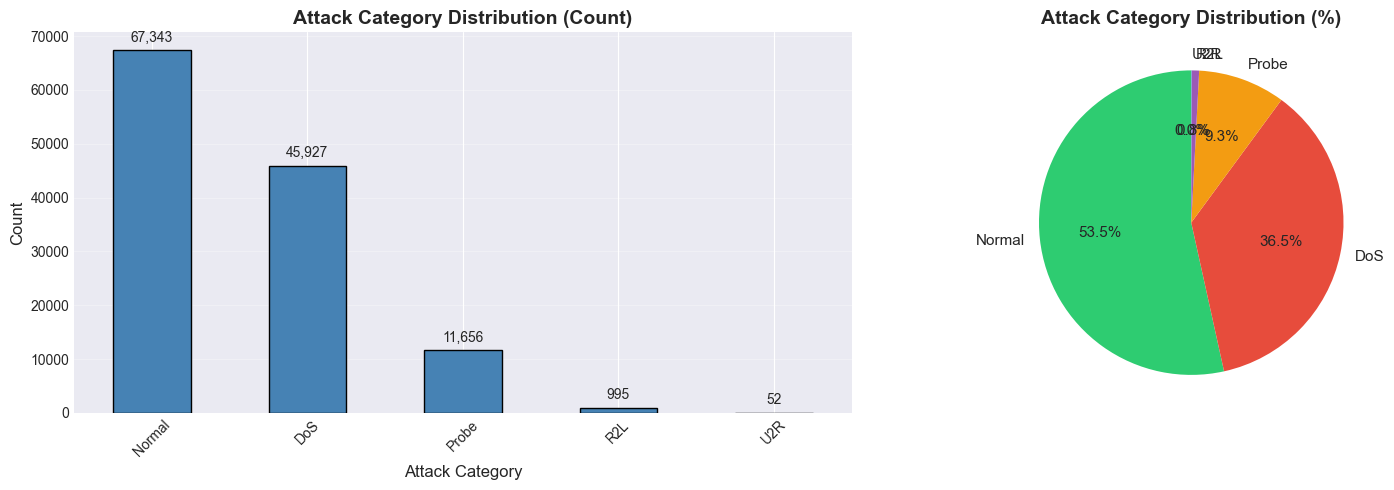


⚠ KEY OBSERVATION: Highly imbalanced dataset!
   - Normal traffic dominates (53.5%)
   - DoS is common (36.5%)
   - Probe is moderate (9.2%)
   - R2L is rare (0.8%)
   - U2R is very rare (0.04%)


In [15]:
# Visualize attack category distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar plot
category_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Attack Category Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Attack Category', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Add count labels on bars
for i, v in enumerate(category_counts):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', va='bottom', fontsize=10)

# Pie chart
colors = ['#2ecc71', '#e74c3c', '#f39c12', '#9b59b6', '#3498db']
category_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90, 
                     colors=colors, textprops={'fontsize': 11})
axes[1].set_title('Attack Category Distribution (%)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print("\n⚠ KEY OBSERVATION: Highly imbalanced dataset!")
print("   - Normal traffic dominates (53.5%)")
print("   - DoS is common (36.5%)")
print("   - Probe is moderate (9.2%)")
print("   - R2L is rare (0.8%)")
print("   - U2R is very rare (0.04%)")

---
## 5. Numerical Features Distribution Analysis

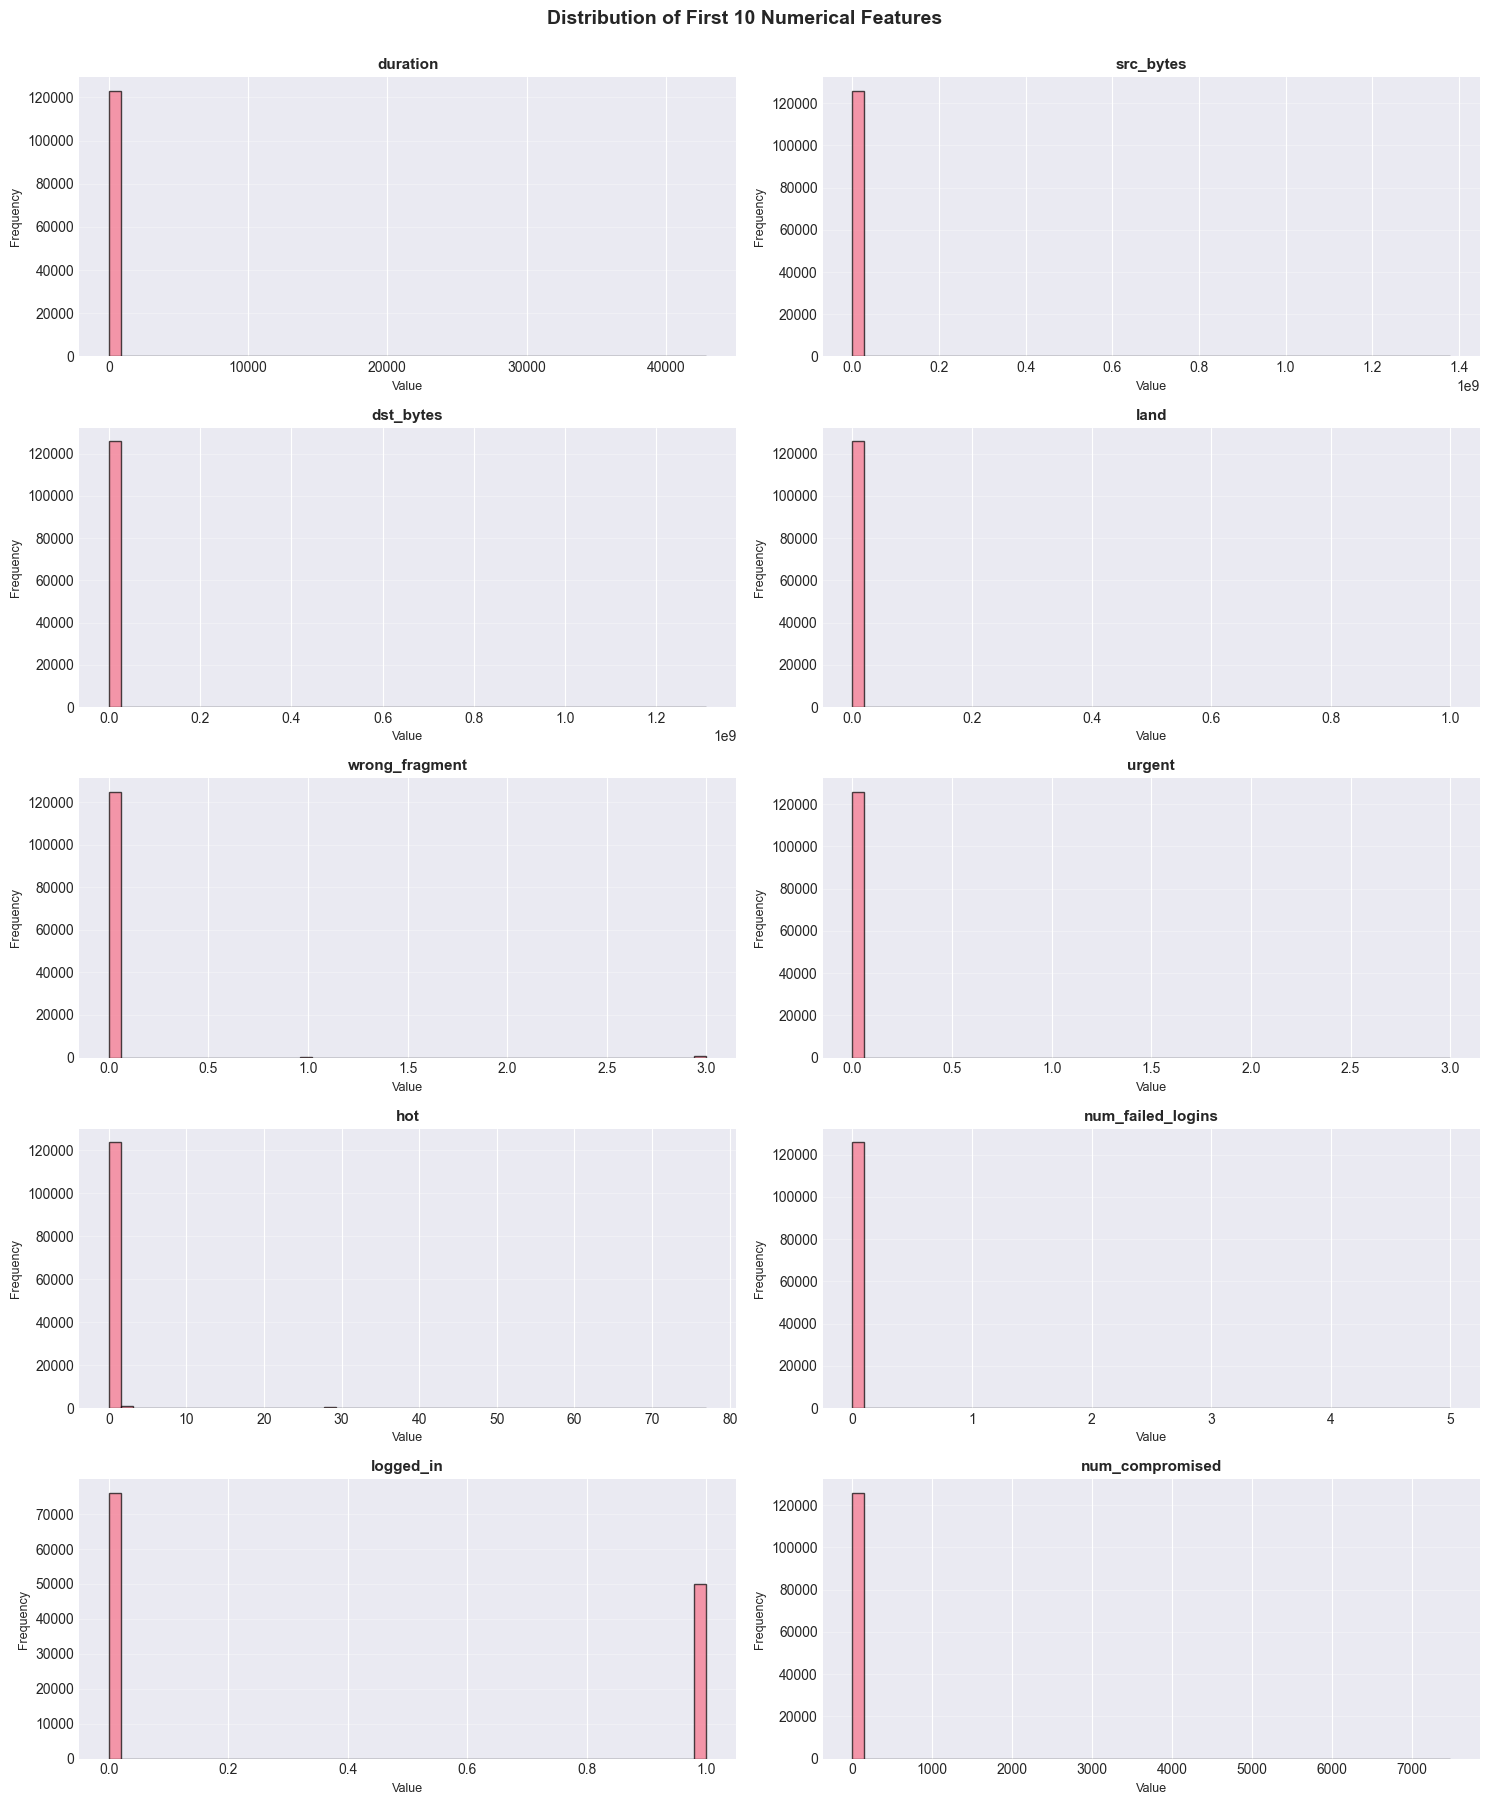

In [16]:
# Select first 10 numerical features for initial exploration
sample_features = numerical_features[:10]

fig, axes = plt.subplots(5, 2, figsize=(15, 18))
axes = axes.ravel()

for idx, feature in enumerate(sample_features):
    axes[idx].hist(df[feature], bins=50, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'{feature}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Value', fontsize=9)
    axes[idx].set_ylabel('Frequency', fontsize=9)
    axes[idx].grid(axis='y', alpha=0.3)

plt.suptitle('Distribution of First 10 Numerical Features', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

In [17]:
# Check for zero-variance or constant features
print("Features with zero or near-zero variance:")
print("-" * 80)

for feature in numerical_features:
    variance = df[feature].var()
    unique_vals = df[feature].nunique()
    
    if variance < 0.01 or unique_vals <= 2:
        print(f"{feature:30s} | Variance: {variance:10.6f} | Unique values: {unique_vals}")

print("\n⚠ Low-variance features may not be useful for unsupervised learning!")

Features with zero or near-zero variance:
--------------------------------------------------------------------------------
land                           | Variance:   0.000198 | Unique values: 2
urgent                         | Variance:   0.000206 | Unique values: 4
num_failed_logins              | Variance:   0.002047 | Unique values: 6
logged_in                      | Variance:   0.239131 | Unique values: 2
root_shell                     | Variance:   0.001340 | Unique values: 2
su_attempted                   | Variance:   0.002039 | Unique values: 3
num_shells                     | Variance:   0.000492 | Unique values: 3
num_access_files               | Variance:   0.009874 | Unique values: 10
num_outbound_cmds              | Variance:   0.000000 | Unique values: 1
is_host_login                  | Variance:   0.000008 | Unique values: 2
is_guest_login                 | Variance:   0.009334 | Unique values: 2

⚠ Low-variance features may not be useful for unsupervised learning!


---
## 6. Feature Correlation Analysis

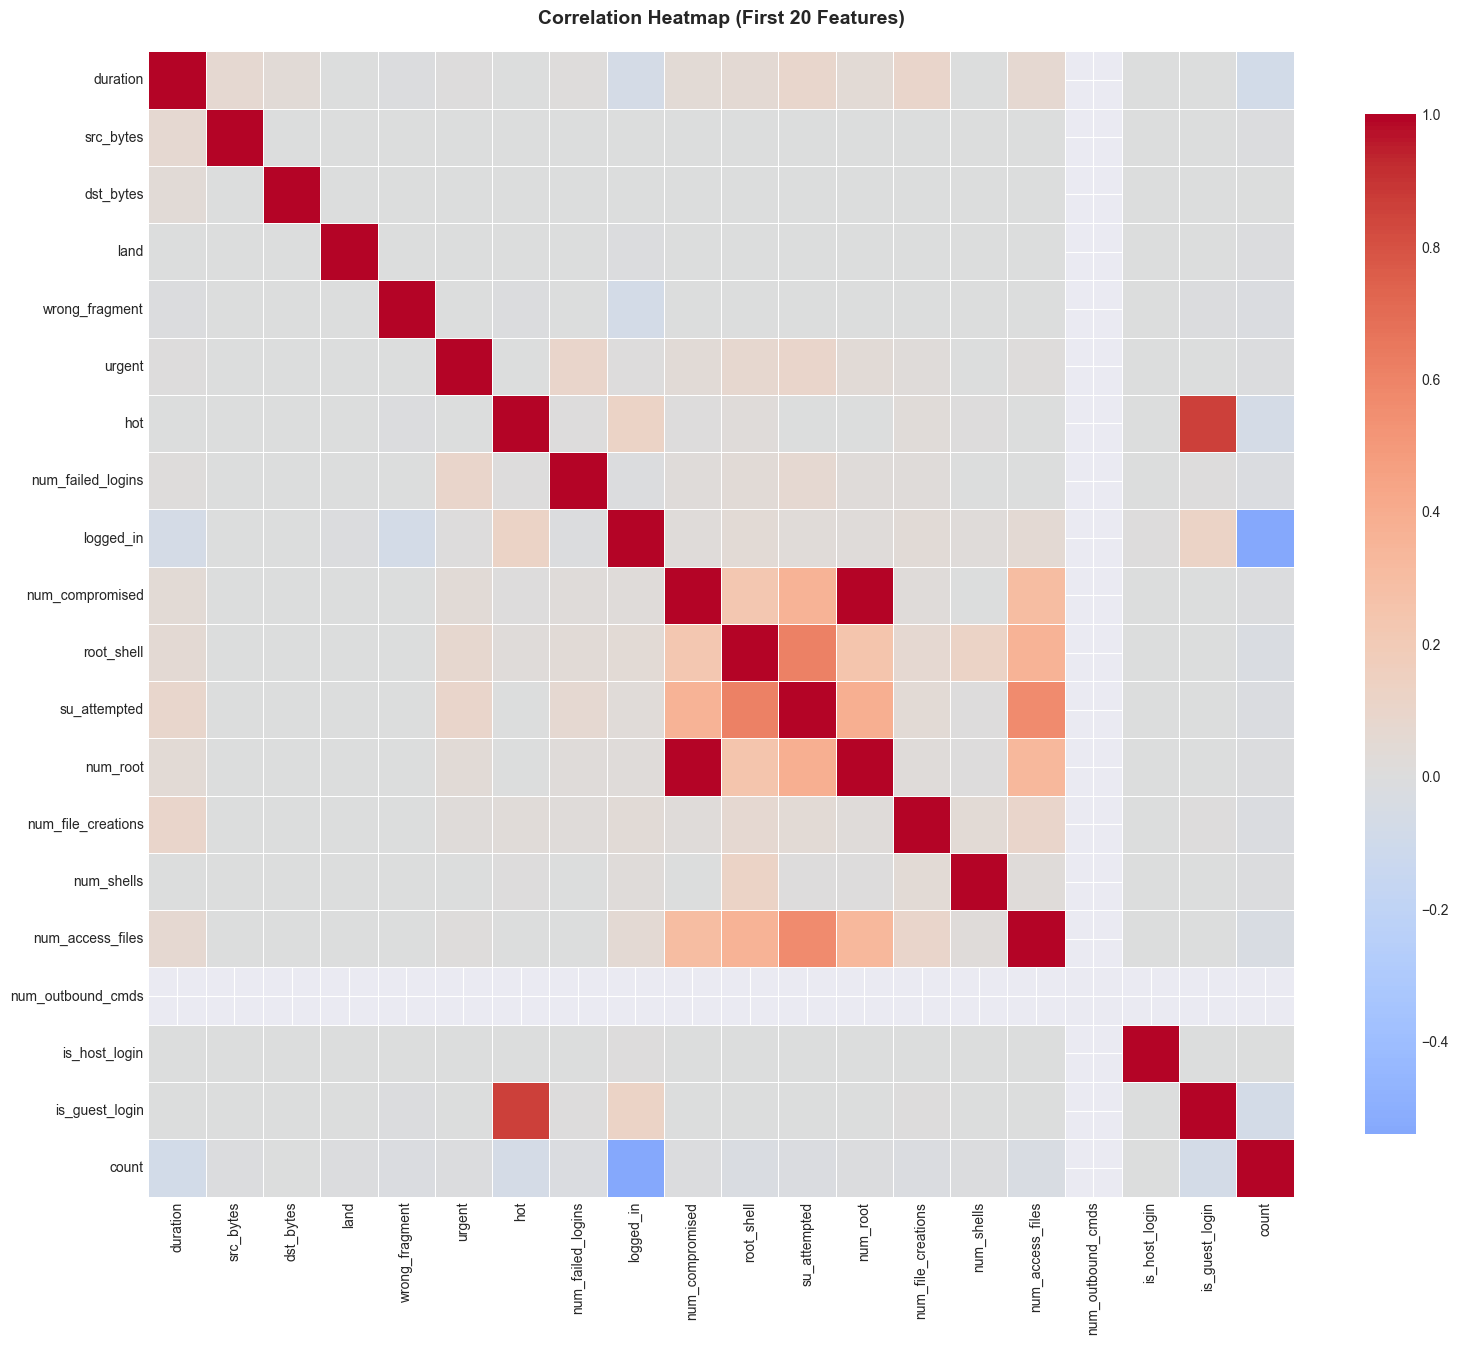

In [18]:
# Compute correlation matrix for numerical features
# Use a subset for better visualization
subset_features = numerical_features[:20]  # First 20 features

corr_matrix = df[subset_features].corr()

# Plot correlation heatmap
plt.figure(figsize=(16, 14))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap (First 20 Features)', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [19]:
# Find highly correlated feature pairs (|correlation| > 0.8)
print("Highly correlated feature pairs (|r| > 0.8):")
print("=" * 80)

high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            high_corr_pairs.append((
                corr_matrix.columns[i], 
                corr_matrix.columns[j], 
                corr_matrix.iloc[i, j]
            ))

if high_corr_pairs:
    for feat1, feat2, corr in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
        print(f"{feat1:30s} <-> {feat2:30s} | r = {corr:6.3f}")
else:
    print("No highly correlated pairs found in first 20 features.")

print("\n💡 Highly correlated features may be redundant - consider removing in preprocessing!")

Highly correlated feature pairs (|r| > 0.8):
num_compromised                <-> num_root                       | r =  0.999
hot                            <-> is_guest_login                 | r =  0.860

💡 Highly correlated features may be redundant - consider removing in preprocessing!


---
## 7. Binary vs Multi-valued Features

In [20]:
# Identify binary features (only 0 and 1 values)
binary_features = []
for feature in numerical_features:
    unique_vals = df[feature].unique()
    if len(unique_vals) == 2 and set(unique_vals).issubset({0, 1}):
        binary_features.append(feature)

print(f"Binary features ({len(binary_features)}):")
for feat in binary_features:
    positive_count = (df[feat] == 1).sum()
    positive_pct = positive_count / len(df) * 100
    print(f"  {feat:30s} | Positive: {positive_count:6d} ({positive_pct:5.2f}%)")

print(f"\nContinuous/multi-valued features: {len(numerical_features) - len(binary_features)}")

Binary features (5):
  land                           | Positive:     25 ( 0.02%)
  logged_in                      | Positive:  49852 (39.57%)
  root_shell                     | Positive:    169 ( 0.13%)
  is_host_login                  | Positive:      1 ( 0.00%)
  is_guest_login                 | Positive:   1187 ( 0.94%)

Continuous/multi-valued features: 33


---
## 8. Key Insights Summary

In [21]:
print("="*80)
print("KEY INSIGHTS FROM EXPLORATORY DATA ANALYSIS")
print("="*80)

print(f"\n1. DATASET SIZE:")
print(f"   - Total records: {len(df):,}")
print(f"   - Total features: {len(numerical_features) + len(categorical_features)}")
print(f"   - Numerical features: {len(numerical_features)}")
print(f"   - Categorical features: {len(categorical_features)}")

print(f"\n2. DATA QUALITY:")
print(f"   - Missing values: {df.isnull().sum().sum()}")
print(f"   - Duplicate rows: {df.duplicated().sum():,} ({df.duplicated().sum()/len(df)*100:.2f}%)")

print(f"\n3. CLASS DISTRIBUTION (highly imbalanced!):")
for category, count in category_counts.items():
    print(f"   - {category:10s}: {count:7,} ({count/len(df)*100:5.2f}%)")

print(f"\n4. FEATURE CHARACTERISTICS:")
print(f"   - Binary features: {len(binary_features)}")
print(f"   - Continuous features: {len(numerical_features) - len(binary_features)}")
print(f"   - Categorical features: {len(categorical_features)}")
print(f"     * protocol_type: {df['protocol_type'].nunique()} unique values")
print(f"     * service: {df['service'].nunique()} unique values")
print(f"     * flag: {df['flag'].nunique()} unique values")

print(f"\n5. NEXT STEPS:")
print(f"   ✓ Feature encoding for categorical variables")
print(f"   ✓ Feature scaling/normalization")
print(f"   ✓ Handle class imbalance (for unsupervised: awareness, not resampling!)")
print(f"   ✓ Remove low-variance or highly correlated features")
print(f"   ✓ Dimensionality reduction (PCA, t-SNE)")
print(f"   ✓ Clustering analysis")
print(f"   ✓ Anomaly detection")

print("\n" + "="*80)

KEY INSIGHTS FROM EXPLORATORY DATA ANALYSIS

1. DATASET SIZE:
   - Total records: 125,973
   - Total features: 41
   - Numerical features: 38
   - Categorical features: 3

2. DATA QUALITY:
   - Missing values: 0
   - Duplicate rows: 0 (0.00%)

3. CLASS DISTRIBUTION (highly imbalanced!):
   - Normal    :  67,343 (53.46%)
   - DoS       :  45,927 (36.46%)
   - Probe     :  11,656 ( 9.25%)
   - R2L       :     995 ( 0.79%)
   - U2R       :      52 ( 0.04%)

4. FEATURE CHARACTERISTICS:
   - Binary features: 5
   - Continuous features: 33
   - Categorical features: 3
     * protocol_type: 3 unique values
     * service: 70 unique values
     * flag: 11 unique values

5. NEXT STEPS:
   ✓ Feature encoding for categorical variables
   ✓ Feature scaling/normalization
   ✓ Handle class imbalance (for unsupervised: awareness, not resampling!)
   ✓ Remove low-variance or highly correlated features
   ✓ Dimensionality reduction (PCA, t-SNE)
   ✓ Clustering analysis
   ✓ Anomaly detection



---
## 9. Save Processed Dataset for Next Notebook

In [22]:
# Save the dataframe with attack categories
df.to_csv('nslkdd_train_with_categories.csv', index=False)
print("✓ Saved: nslkdd_train_with_categories.csv")

# Also save feature lists for easy access
import json

feature_info = {
    'categorical_features': categorical_features,
    'numerical_features': numerical_features,
    'binary_features': binary_features,
    'all_features': numerical_features + categorical_features
}

with open('feature_info.json', 'w') as f:
    json.dump(feature_info, f, indent=2)

print("✓ Saved: feature_info.json")
print("\n🎯 Ready for Notebook 2: Data Preprocessing & Feature Engineering!")

✓ Saved: nslkdd_train_with_categories.csv
✓ Saved: feature_info.json

🎯 Ready for Notebook 2: Data Preprocessing & Feature Engineering!


---
## 📊 What We Learned

1. **Dataset has 125,973 records with 41 features**
2. **5 attack categories: Normal (53%), DoS (37%), Probe (9%), R2L (1%), U2R (0.04%)**
3. **Highly imbalanced dataset** - U2R attacks are extremely rare!
4. **No missing values** - clean dataset
5. **Mix of binary, continuous, and categorical features**
6. **Some features have low variance** - may not be useful
7. **Some features are highly correlated** - redundancy to address

**Next Steps:**
- Notebook 2: Preprocessing (encoding, scaling, feature selection)
- Notebook 3: Dimensionality reduction (PCA, t-SNE, UMAP)
- Notebook 4: Clustering analysis
- Notebook 5: Anomaly detection
- Notebook 6: Evaluation & insights